In [2]:
from google.colab import drive
drive.mount('/content/drive',force_remount= True)

Mounted at /content/drive


In [3]:
!cp /content/drive/MyDrive/ginko_2025/Image_dataset.7z /content/
!cp /content/drive/MyDrive/ginko_2025/features_all_.csv /content/

!7z x -y /content/Image_dataset.7z -mmt=on
# !cp /content/drive/MyDrive/ginko_2025/features_all_.csv /content/
# !unzip /content/ginko_links.zip
# !rm -r /content/ginko_links.zip


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,12 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (50657),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/                   1 file, 6258770285 bytes (5969 MiB)

Extracting archive: /content/Image_dataset.7z
--
Path = /content/Image_dataset.7z
Type = 7z
Physical Size = 6258770285
Headers Size = 2997647
Method = LZMA:23
Solid = +
Blocks = 1

  0%      0% - image_dataset/LWF/65_0.jpg                                   0% 119 - image_dataset/LWF/65_5195.jpg                                          0% 223 - image_dataset/LWF/80_2902.jpg                                          0% 3

# Import Libraries

In [4]:
import os
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

In [5]:
print(f'TensorFlow version {tf.__version__}')

TensorFlow version 2.17.1


In [6]:
df = pd.read_csv('/content/features_all_.csv', index_col=0)
df

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,power,path_spec,class
0,0.0020,0.0,17.744577,14.204046,17.744577,-12.0,12.0,24.0,-0.039891,2.899677,4.269320,-703125.00,0.000292,0.000064,0.920913,0.004744,0,/image_dataset/CLEAN/CLEAN_0_0.jpg,CLEAN
1,0.8395,1.0,18.035458,14.317994,18.054985,-12.0,13.0,25.0,0.022366,3.047947,4.308006,-4316406.25,0.000303,0.000062,0.927665,0.001548,0,/image_dataset/CLEAN/CLEAN_0_1.jpg,CLEAN
2,0.7320,1.0,18.236013,14.461431,18.250698,-12.0,13.0,25.0,0.025883,3.022029,4.299705,-664062.50,0.000284,0.000067,0.920649,0.003162,0,/image_dataset/CLEAN/CLEAN_0_2.jpg,CLEAN
3,0.7930,0.0,18.720877,15.026653,18.737663,-12.0,13.0,25.0,0.128283,2.883161,4.340691,878906.25,0.000341,0.000069,0.928678,0.001751,0,/image_dataset/CLEAN/CLEAN_0_3.jpg,CLEAN
4,0.5900,1.0,18.161825,14.478229,18.171406,-12.0,12.0,24.0,0.040069,2.984822,4.293713,-3886718.75,0.000282,0.000068,0.929802,0.005624,0,/image_dataset/CLEAN/CLEAN_0_4.jpg,CLEAN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224225,0.4585,0.0,23.451403,18.869333,23.455885,-15.0,16.0,31.0,-0.009484,2.638786,4.543219,-4394531.25,0.001574,0.000108,0.779902,0.016815,65,/image_dataset/TRI/65_6105.jpg,TRI
224226,-0.2295,0.0,23.386019,18.796106,23.387144,-16.0,15.0,31.0,0.024011,2.660572,4.535358,-4394531.25,0.001577,0.000109,0.781451,0.013389,65,/image_dataset/TRI/65_6106.jpg,TRI
224227,-0.6855,0.0,23.420496,18.852184,23.430525,-16.0,15.0,31.0,0.031016,2.627854,4.548787,-4394531.25,0.001547,0.000109,0.775223,0.017155,65,/image_dataset/TRI/65_6107.jpg,TRI
224228,-0.6415,-1.0,22.220463,17.153934,22.229721,-14.0,12.0,26.0,0.049290,2.961136,4.472224,-4394531.25,0.001259,0.000098,0.828606,0.014379,65,/image_dataset/TRI/65_6108.jpg,TRI


In [7]:
df = df.dropna()
df.shape

[]


(224230, 19)

In [8]:
unique_values = df['power'].unique()
unique_values

array([ 0, 60, 80, 65, 85, 55, 70, 75])

In [9]:
df['class'] = df['class'] + '_' + df['power'].astype(str)
df

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,power,path_spec,class
0,0.0020,0.0,17.744577,14.204046,17.744577,-12.0,12.0,24.0,-0.039891,2.899677,4.269320,-703125.00,0.000292,0.000064,0.920913,0.004744,0,/image_dataset/CLEAN/CLEAN_0_0.jpg,CLEAN_0
1,0.8395,1.0,18.035458,14.317994,18.054985,-12.0,13.0,25.0,0.022366,3.047947,4.308006,-4316406.25,0.000303,0.000062,0.927665,0.001548,0,/image_dataset/CLEAN/CLEAN_0_1.jpg,CLEAN_0
2,0.7320,1.0,18.236013,14.461431,18.250698,-12.0,13.0,25.0,0.025883,3.022029,4.299705,-664062.50,0.000284,0.000067,0.920649,0.003162,0,/image_dataset/CLEAN/CLEAN_0_2.jpg,CLEAN_0
3,0.7930,0.0,18.720877,15.026653,18.737663,-12.0,13.0,25.0,0.128283,2.883161,4.340691,878906.25,0.000341,0.000069,0.928678,0.001751,0,/image_dataset/CLEAN/CLEAN_0_3.jpg,CLEAN_0
4,0.5900,1.0,18.161825,14.478229,18.171406,-12.0,12.0,24.0,0.040069,2.984822,4.293713,-3886718.75,0.000282,0.000068,0.929802,0.005624,0,/image_dataset/CLEAN/CLEAN_0_4.jpg,CLEAN_0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224225,0.4585,0.0,23.451403,18.869333,23.455885,-15.0,16.0,31.0,-0.009484,2.638786,4.543219,-4394531.25,0.001574,0.000108,0.779902,0.016815,65,/image_dataset/TRI/65_6105.jpg,TRI_65
224226,-0.2295,0.0,23.386019,18.796106,23.387144,-16.0,15.0,31.0,0.024011,2.660572,4.535358,-4394531.25,0.001577,0.000109,0.781451,0.013389,65,/image_dataset/TRI/65_6106.jpg,TRI_65
224227,-0.6855,0.0,23.420496,18.852184,23.430525,-16.0,15.0,31.0,0.031016,2.627854,4.548787,-4394531.25,0.001547,0.000109,0.775223,0.017155,65,/image_dataset/TRI/65_6107.jpg,TRI_65
224228,-0.6415,-1.0,22.220463,17.153934,22.229721,-14.0,12.0,26.0,0.049290,2.961136,4.472224,-4394531.25,0.001259,0.000098,0.828606,0.014379,65,/image_dataset/TRI/65_6108.jpg,TRI_65


In [10]:
df.dtypes

,0
f1,float64
f2,float64
f3,float64
f4,float64
f5,float64
f6,float64
f7,float64
f8,float64
f9,float64
f10,float64


# Preprocessing images

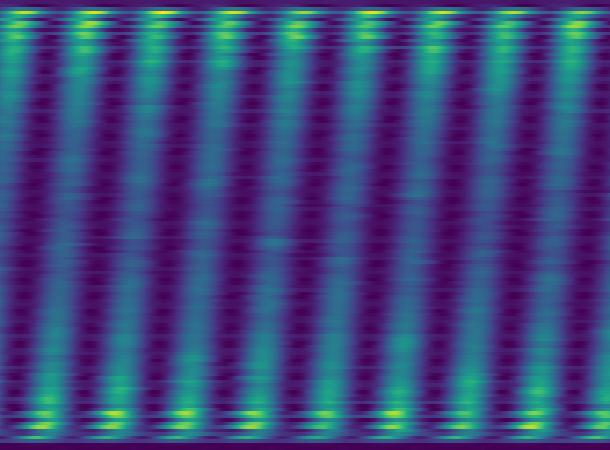

In [11]:
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

image = cv2.imread("/content"  + df.iloc[180000]['path_spec'])
cv2_imshow(image)

# Monitor features

In [12]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

df.iloc[:,0:-3] = scaler.fit_transform(df.iloc[:,0:-3].to_numpy())
df

,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,power,path_spec,class
0,0.519869,0.500,0.277232,0.333006,0.275798,0.444444,0.588235,0.588235,0.372548,0.352670,0.608784,0.422535,0.027797,0.272203,0.909176,0.067258,0,/image_dataset/CLEAN/CLEAN_0_0.jpg,CLEAN_0
1,0.709498,0.625,0.296334,0.341768,0.296147,0.444444,0.647059,0.617647,0.473517,0.390106,0.638907,0.050302,0.029834,0.259615,0.936808,0.015915,0,/image_dataset/CLEAN/CLEAN_0_1.jpg,CLEAN_0
2,0.685158,0.625,0.309504,0.352798,0.308977,0.444444,0.647059,0.617647,0.479220,0.383562,0.632443,0.426559,0.026261,0.296843,0.908094,0.041843,0,/image_dataset/CLEAN/CLEAN_0_2.jpg,CLEAN_0
3,0.698970,0.500,0.341345,0.396261,0.340900,0.444444,0.647059,0.617647,0.645293,0.348500,0.664357,0.585513,0.036843,0.308775,0.940953,0.019178,0,/image_dataset/CLEAN/CLEAN_0_3.jpg,CLEAN_0
4,0.653006,0.625,0.304632,0.354090,0.303779,0.444444,0.588235,0.588235,0.502227,0.374168,0.627778,0.094567,0.025877,0.301747,0.945554,0.081391,0,/image_dataset/CLEAN/CLEAN_0_4.jpg,CLEAN_0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224225,0.623231,0.500,0.651992,0.691749,0.650204,0.277778,0.823529,0.794118,0.421862,0.286798,0.822058,0.042254,0.265986,0.630390,0.332120,0.261151,65,/image_dataset/TRI/65_6105.jpg,TRI_65
224226,0.467452,0.500,0.647698,0.686118,0.645698,0.222222,0.764706,0.794118,0.476184,0.292299,0.815937,0.042254,0.266542,0.638970,0.338457,0.206124,65,/image_dataset/TRI/65_6106.jpg,TRI_65
224227,0.364202,0.500,0.649962,0.690430,0.648542,0.222222,0.764706,0.794118,0.487546,0.284038,0.826393,0.042254,0.260962,0.638473,0.312974,0.266611,65,/image_dataset/TRI/65_6107.jpg,TRI_65
224228,0.374165,0.375,0.571158,0.559841,0.569823,0.333333,0.588235,0.647059,0.517182,0.368187,0.766776,0.042254,0.207316,0.549693,0.531429,0.222030,65,/image_dataset/TRI/65_6108.jpg,TRI_65


# Get Labels , Images , Features

In [13]:
full_features = df.iloc[:,0:-3].to_numpy()
full_images = df['path_spec'].to_numpy()
full_images = "/content" + full_images
full_labels = df['class'].to_numpy()

# OneHot Labels for Classification

In [14]:
label_encoder = LabelEncoder()
onehot_encoder = OneHotEncoder(sparse_output=False)

full_labels = label_encoder.fit_transform(full_labels)
full_labels = full_labels.reshape(len(full_labels), 1)
full_labels = onehot_encoder.fit_transform(full_labels)
full_labels.shape

(224230, 36)

In [15]:
train_images, test_images,  train_features ,test_features , train_labels,test_labels = train_test_split(full_images,full_features,full_labels, test_size=0.5, random_state=1,shuffle=True)

valid_images, test_images,  valid_features ,test_features , valid_labels,test_labels = train_test_split(test_images,test_features,test_labels, test_size=0.75, random_state=1, shuffle=True)


In [16]:
print('train : ' ,train_images.shape[0])
print(np.unique(np.argmax(train_labels,axis = 1),return_counts=True))
print('validation : ' ,valid_images.shape[0])
print(np.unique(np.argmax(valid_labels,axis = 1),return_counts=True))
print('test : ' ,test_images.shape[0])
print(np.unique(np.argmax(test_labels,axis = 1),return_counts=True))

train :  112115
(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35]), array([5959, 3075, 2937, 3167, 2979, 3007, 2997, 2996, 3018, 3127, 3039,
       3082, 3047, 3043, 3052, 3060, 2997, 2977, 3061, 3041, 3043, 2999,
       3038, 3010, 3025, 3054, 3066, 2988, 3034, 3076, 3026, 3021, 3018,
       2977, 3038, 3041]))
validation :  28028
(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35]), array([1514,  718,  736,  777,  740,  774,  775,  741,  767,  783,  764,
        759,  753,  753,  745,  724,  754,  810,  719,  716,  731,  789,
        754,  762,  819,  746,  752,  759,  775,  733,  791,  757,  787,
        738,  741,  772]))
test :  84087
(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26,

In [17]:
n_features = train_features.shape[1]
print(f'Total number of aided features: {n_features}')

Total number of aided features: 16


In [18]:
n_labels = len(onehot_encoder.categories_[0])
print(f'Total number of classes in the dataset: {n_labels}')

Total number of classes in the dataset: 36


In [19]:
def get_images(feature,image,label) :
  img = tf.io.read_file(image)

  return feature , img, label

def process_image(feature,image,label):
  img = tf.image.decode_jpeg(image, channels=3)
  #img = img[22:-46,69:-1]
  img = tf.image.resize(img,(224,224))
  img = tf.cast(img,tf.float32)

  return (feature,img) , label

In [20]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
X1 = X2 = X3 =  AUTOTUNE
validation = tf.data.Dataset.from_tensor_slices((valid_features,valid_images,valid_labels))
validation = validation.map(get_images,num_parallel_calls=X1)
validation = validation.map(process_image,num_parallel_calls=X2)
validation = validation.batch(batch_size=64)
validation = validation.prefetch(buffer_size=X3)

AUTOTUNE = tf.data.experimental.AUTOTUNE
Z1 = Z2 = Z3 =  AUTOTUNE
test = tf.data.Dataset.from_tensor_slices((test_features,test_images,test_labels))
test = test.map(get_images,num_parallel_calls=Z1)
test = test.map(process_image,num_parallel_calls=Z2)
test = test.batch(batch_size=64)
test = test.prefetch(buffer_size=Z3)


AUTOTUNE2 = tf.data.experimental.AUTOTUNE
Y1 = Y2 = Y3  = AUTOTUNE2
train = tf.data.Dataset.from_tensor_slices((train_features,train_images,train_labels))
train = train.shuffle(len(train_features))
train = train.map(get_images,num_parallel_calls=Y1)
train = train.map(process_image,num_parallel_calls=Y2)
train = train.batch(batch_size=64)
train = train.prefetch(buffer_size=Y3)

# Create the model

In [21]:
import tensorflow
import tensorflow.keras as keras
from tensorflow.keras import models
from tensorflow.keras.layers import Dropout, Conv2D,MaxPooling2D, Concatenate, Conv2DTranspose, BatchNormalization, LeakyReLU, GlobalAveragePooling2D, multiply,add

Model_name = 'ginko_CNN_Resnet_10MHz_sc8_W-f'
base_model = keras.applications.ResNet50(include_top = False,input_shape=(224,224,3),weights = None)

# Model_name = 'ginko_CNN_MobileNet_10MHz_sc8_W-f'
# base_model = keras.applications.MobileNetV2(include_top = False,input_shape=(224,224,3),weights = None)

# Model_name = 'ginko_CNN_EfficientNet_10MHz_sc8_W-f'
# base_model = keras.applications.EfficientNetB0(include_top = False,input_shape=(224,224,3),weights = None)


avgPooling = keras.layers.GlobalAveragePooling2D()(base_model.output)
features_input = keras.Input(shape = (n_features,))
concat = keras.layers.Concatenate()([features_input,avgPooling])
x = keras.layers.Dense(2048, activation='relu')(concat)
x = keras.layers.Dropout(0.5)(x)
x = keras.layers.Dense(2048, activation='relu')(x)
output = keras.layers.Dense(n_labels,activation = 'softmax')(x)
model = tf.keras.Model(inputs = [features_input,base_model.input],outputs = output)

model.trainable = True
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='categorical_crossentropy',metrics=['acc'])

# Trasfer Learning

In [22]:
# Download Model from google colab
#!cp /content/drive/MyDrive/ginko_LINKS/all_samples/ginko_ML_25MHz_sc16_Resnet.h5 /content/
#model.load_weights('ginko_ML_25MHz_sc16_Resnet.h5')
#from sklearn.metrics import classification_report
#target_names = label_encoder.classes_
#test_pred = model.predict(test)
#print(classification_report(np.argmax(test_labels,axis = 1), np.argmax(test_pred,axis = 1), target_names=target_names))
import os
os.makedirs(f'{Model_name}/trained_model', exist_ok=True)

# Learning

In [23]:
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(f'{Model_name}.weights.h5', monitor='val_loss', mode='min', verbose=1, save_best_only=True, save_weights_only=True)
reduce_lr= keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=2, min_lr = 1e-6, verbose = 1)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, verbose=1, mode="min")
history = model.fit(train, epochs=20, validation_data=validation, callbacks=[checkpoint_callback,early_stopping,reduce_lr])

Epoch 1/20
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - acc: 0.5409 - loss: 1.4407
Epoch 1: val_loss improved from inf to 4.65954, saving model to Atlantis_CNN_Resnet_10MHz_sc8_W-f.weights.h5
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 284s 113ms/step - acc: 0.5410 - loss: 1.4402 - val_acc: 0.4771 - val_loss: 4.6595 - learning_rate: 0.0010
Epoch 2/20
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - acc: 0.9325 - loss: 0.1898
Epoch 2: val_loss improved from 4.65954 to 1.74129, saving model to Atlantis_CNN_Resnet_10MHz_sc8_W-f.weights.h5
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 157s 90ms/step - acc: 0.9325 - loss: 0.1898 - val_acc: 0.7288 - val_loss: 1.7413 - learning_rate: 0.0010
Epoch 3/20
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - acc: 0.9589 - loss: 0.1234
Epoch 3: val_loss did not improve from 1.74129
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 156s 89ms/step - acc: 0.9589 - loss: 0.1234 - val_acc: 0.4881 - val_loss: 5.9865 - learning_rate: 0.0010
Epoch 4/20
1752/1752 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - acc: 0.9749 -

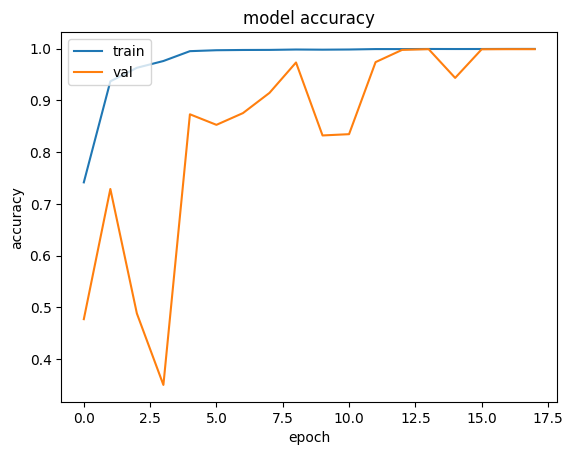

In [24]:
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

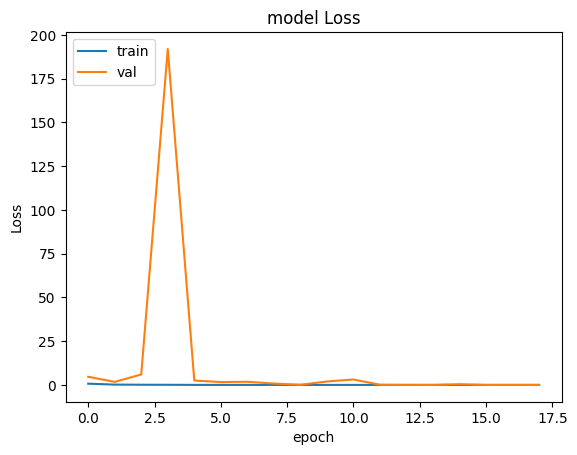

In [25]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model Loss')
plt.ylabel('Loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [26]:
from sklearn.metrics import classification_report
target_names = label_encoder.classes_
model.load_weights(f'{Model_name}.weights.h5')
test_pred = model.predict(test)
print(classification_report(np.argmax(test_labels,axis = 1), np.argmax(test_pred,axis = 1), target_names=target_names, digits=4))

1314/1314 ━━━━━━━━━━━━━━━━━━━━ 41s 28ms/step
              precision    recall  f1-score   support

     CLEAN_0     0.9967    0.9991    0.9979      4527
       LN_55     1.0000    0.9996    0.9998      2247
       LN_60     0.9996    1.0000    0.9998      2367
       LN_65     1.0000    1.0000    1.0000      2416
       LN_70     1.0000    1.0000    1.0000      2191
       LN_75     1.0000    1.0000    1.0000      2269
       LN_80     1.0000    1.0000    1.0000      2278
       LN_85     1.0000    0.9992    0.9996      2363
      LWF_55     1.0000    1.0000    1.0000      2235
      LWF_60     1.0000    1.0000    1.0000      2310
      LWF_65     1.0000    1.0000    1.0000      2287
      LWF_70     1.0000    1.0000    1.0000      2189
      LWF_75     1.0000    1.0000    1.0000      2290
      LWF_80     1.0000    1.0000    1.0000      2274
      LWF_85     1.0000    0.9987    0.9993      2223
     TICK_55     0.9909    0.9996    0.9952      2276
     TICK_60     0.9996    0.9912   

In [27]:
from sklearn.metrics import f1_score, precision_score, recall_score

# Print f1, precision, and recall scores
print(precision_score(np.argmax(test_labels,axis = 1), np.argmax(test_pred,axis = 1) , average="macro"))
print(recall_score(np.argmax(test_labels,axis = 1), np.argmax(test_pred,axis = 1) , average="macro"))
print(f1_score(np.argmax(test_labels,axis = 1), np.argmax(test_pred,axis = 1) , average="macro"))

0.999518789562778
0.9994475814035337
0.9994820647794496


In [28]:
evaluate = model.evaluate(test)

1314/1314 ━━━━━━━━━━━━━━━━━━━━ 36s 27ms/step - acc: 0.9995 - loss: 0.0019


In [31]:
target_names2= target_names
target_names

array(['CLEAN_0', 'LN_55', 'LN_60', 'LN_65', 'LN_70', 'LN_75', 'LN_80',
       'LN_85', 'LWF_55', 'LWF_60', 'LWF_65', 'LWF_70', 'LWF_75',
       'LWF_80', 'LWF_85', 'TICK_55', 'TICK_60', 'TICK_65', 'TICK_70',
       'TICK_75', 'TICK_80', 'TICK_85', 'TRI_55', 'TRI_60', 'TRI_65',
       'TRI_70', 'TRI_75', 'TRI_80', 'TRI_85', 'TW_55', 'TW_60', 'TW_65',
       'TW_70', 'TW_75', 'TW_80', 'TW_85'], dtype=object)

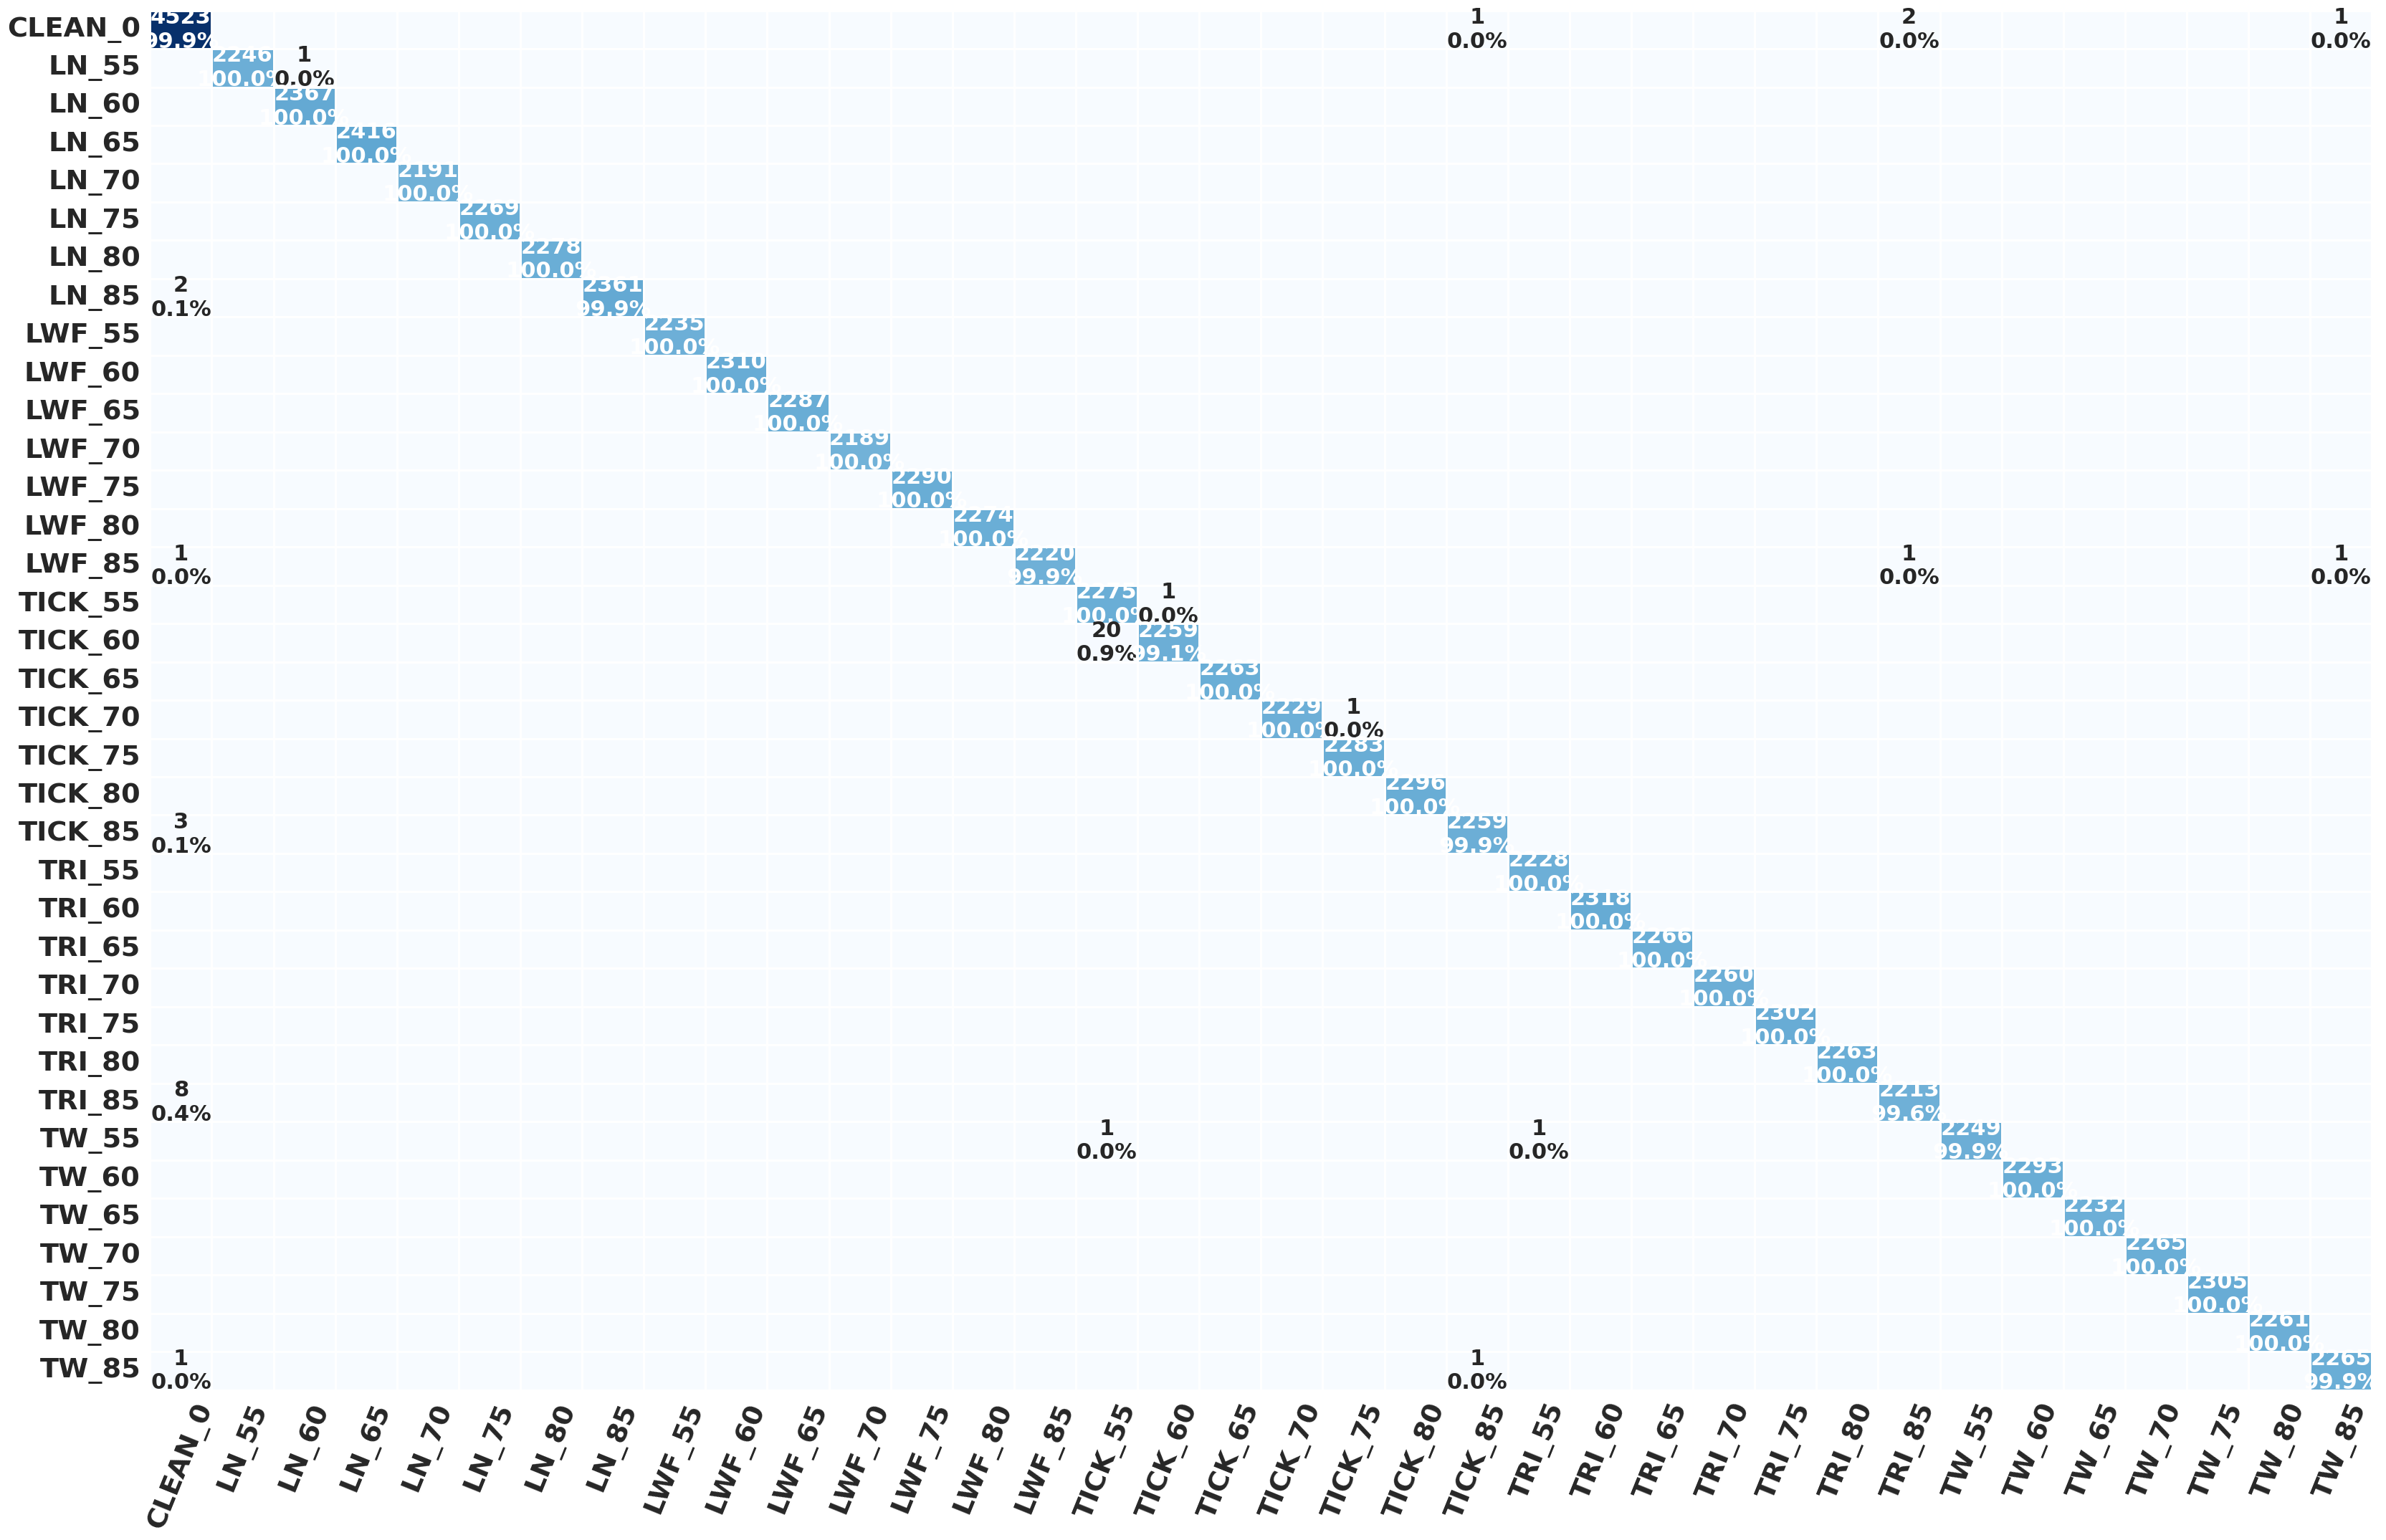

In [32]:
from matplotlib.figure import cbar
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(np.argmax(test_labels,axis = 1), np.argmax(test_pred,axis = 1))
df_ = pd.DataFrame(cm)
# df =df.replace(0, ' ')
# print(df)
#Create perc to store the percentages for each column using DIV.
perc = df_.copy()
cols=perc.columns.values
perc[cols]=perc[cols].div(perc[cols].sum(axis=1), axis=0).multiply(100)

#Use annot to store the text value to display in each cell. Number \n Percent % format
annot=df_.round(2).astype(str) + "\n" + perc.round(1).astype(str) + "%"
annot =annot.replace('0\n0.0%', ' ')
sns.set(font_scale=2.5)

#Create plot - adjust size, linewidth and provide annotation text for display
fig, ax = plt.subplots(figsize=(40,25))
g = sns.heatmap(cm, annot=annot, fmt='',xticklabels=target_names2, yticklabels=target_names2,cmap = "Blues",
            annot_kws={"fontsize":22,'weight': 'bold'}, linewidth=1, ax=ax,cbar = False)

g.set_xticklabels(g.get_xticklabels(), rotation=68,fontdict={'weight': 'bold'})
g.set_yticklabels(g.get_yticklabels(),fontdict={'weight': 'bold'})

plt.savefig('filename.pdf',bbox_inches='tight', pad_inches=0)

plt.show(block=False)

In [33]:
for i in range(len(target_names)):
    print('accuracy of '+ target_names[i] + ' : ' + perc.iloc[i,i].round(2).astype(str))

accuracy of CLEAN_0 : 99.91
accuracy of LN_55 : 99.96
accuracy of LN_60 : 100.0
accuracy of LN_65 : 100.0
accuracy of LN_70 : 100.0
accuracy of LN_75 : 100.0
accuracy of LN_80 : 100.0
accuracy of LN_85 : 99.92
accuracy of LWF_55 : 100.0
accuracy of LWF_60 : 100.0
accuracy of LWF_65 : 100.0
accuracy of LWF_70 : 100.0
accuracy of LWF_75 : 100.0
accuracy of LWF_80 : 100.0
accuracy of LWF_85 : 99.87
accuracy of TICK_55 : 99.96
accuracy of TICK_60 : 99.12
accuracy of TICK_65 : 100.0
accuracy of TICK_70 : 99.96
accuracy of TICK_75 : 100.0
accuracy of TICK_80 : 100.0
accuracy of TICK_85 : 99.87
accuracy of TRI_55 : 100.0
accuracy of TRI_60 : 100.0
accuracy of TRI_65 : 100.0
accuracy of TRI_70 : 100.0
accuracy of TRI_75 : 100.0
accuracy of TRI_80 : 100.0
accuracy of TRI_85 : 99.64
accuracy of TW_55 : 99.91
accuracy of TW_60 : 100.0
accuracy of TW_65 : 100.0
accuracy of TW_70 : 100.0
accuracy of TW_75 : 100.0
accuracy of TW_80 : 100.0
accuracy of TW_85 : 99.91


# Save the model, Scaler and Labels

In [34]:
import tf2onnx
import onnx

trained_model = os.path.join(Model_name, 'trained_model')

# load the best model
model.load_weights(Model_name + '.weights.h5')

# Save the best model
model.save(f'{trained_model}/{Model_name}.keras')
model.save(f'{trained_model}/{Model_name}.h5')

# Export the model as Saved_Model format (contains .pb file)
model.export(f'{trained_model}/{Model_name}', format="tf_saved_model")

# Export the model as ONNX (Open Neural Network Exchange) format
# model.export(f'{trained_model}/{Model_name}.onxx', format="onnx")

import onnx
# Dynamically create input_signature
input_signature = [
    tf.TensorSpec(shape=input.shape[:], dtype=input.dtype, name=input.name.split(":")[0])
    for input in model.inputs
]
onnx_model, _ = tf2onnx.convert.from_keras(model, input_signature, opset=13)
onnx.save(onnx_model, f'{trained_model}/{Model_name}.onnx')

Saved artifact at 'Atlantis_CNN_Resnet_10MHz_sc8_W-f/trained_model/Atlantis_CNN_Resnet_10MHz_sc8_W-f'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 16), dtype=tf.float32, name='keras_tensor_176'), TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')]
Output Type:
  TensorSpec(shape=(None, 36), dtype=tf.float32, name=None)
Captures:
  140646756411792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140646756416400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140646756415824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140646756416592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140646756415632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140646756413136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140646690670928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140646690672080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140646690

In [35]:
import joblib
joblib.dump(scaler, f'{Model_name}/scaler_model.pkl')
joblib.dump(target_names, f'{Model_name}/target_names.pkl')

!zip -r ginko_CNN_Resnet_10MHz_sc8_W-f.zip ginko_CNN_Resnet_10MHz_sc8_W-f
!cp ginko_CNN_Resnet_10MHz_sc8_W-f.zip /content/drive/MyDrive/ginko_2025/

  adding: Atlantis_CNN_Resnet_10MHz_sc8_W-f/ (stored 0%)
  adding: Atlantis_CNN_Resnet_10MHz_sc8_W-f/scaler_model.pkl (deflated 25%)
  adding: Atlantis_CNN_Resnet_10MHz_sc8_W-f/target_names.pkl (deflated 43%)
  adding: Atlantis_CNN_Resnet_10MHz_sc8_W-f/trained_model/ (stored 0%)
  adding: Atlantis_CNN_Resnet_10MHz_sc8_W-f/trained_model/Atlantis_CNN_Resnet_10MHz_sc8_W-f.keras (deflated 14%)
  adding: Atlantis_CNN_Resnet_10MHz_sc8_W-f/trained_model/Atlantis_CNN_Resnet_10MHz_sc8_W-f.onnx (deflated 7%)
  adding: Atlantis_CNN_Resnet_10MHz_sc8_W-f/trained_model/Atlantis_CNN_Resnet_10MHz_sc8_W-f.h5 (deflated 14%)
  adding: Atlantis_CNN_Resnet_10MHz_sc8_W-f/trained_model/Atlantis_CNN_Resnet_10MHz_sc8_W-f/ (stored 0%)
  adding: Atlantis_CNN_Resnet_10MHz_sc8_W-f/trained_model/Atlantis_CNN_Resnet_10MHz_sc8_W-f/assets/ (stored 0%)
  adding: Atlantis_CNN_Resnet_10MHz_sc8_W-f/trained_model/Atlantis_CNN_Resnet_10MHz_sc8_W-f/fingerprint.pb (stored 0%)
  adding: Atlantis_CNN_Resnet_10MHz_sc8_W-f/traine

# Inference on single image

<ipython-input-39-030f88690eb6>:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  image_path = "/content" + row[-2]


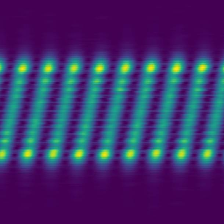

37658: The true label of this sample is LN_55 55
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
LN_60


In [39]:
import random
random_number = random.randint(0, 224230)
row = df.iloc[random_number]
from google.colab.patches import cv2_imshow
import cv2

image_path = "/content" + row[-2]
image = cv2.imread(image_path)
# image = image[30:-56,79:-12]
# cv2_imshow(image)
image = cv2.resize(image,(224,224))
cv2_imshow(image)

features = row[0:-3]
print(f'{random_number}: The true label of this sample is {row["class"]} {row["power"]}')

input = (np.expand_dims(features.astype(np.float32),0),np.expand_dims(image.astype(np.float32),0))
output = model.predict(input)
print(target_names[np.argmax(output)])